In [5]:
import onep
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy
%matplotlib inline

In [6]:
# Mice grouped by sex and ID
female_mice = [f"astroF{i}" for i in [3, 5, 6, 7, 8, 9, 10]]
male_mice = [f"astroM{i}" for i in range(3, 11)]

# Combine and tag sex
all_mice = [{'id': m, 'sex': 'F'} for m in female_mice] + [{'id': m, 'sex': 'M'} for m in male_mice]

In [7]:
import os

def load_sessions(mice, session, base_path, verbose=True):
    objects = {}
    for mouse in mice:
        m_id = mouse['id']
        try:
            if verbose:
                print(f"Loading: {m_id} | Session: {session}")

            proc = onep.InscopixProcessing(m_id, session, base_path)

            # Check for expected AnyMaze file
            if not os.path.isfile(proc.anymaze):
                if verbose:
                    print(f"Missing AnyMaze file for {m_id}, skipping.")
                continue

            proc.read_inscopix()
            proc.run_behavior_analysis()
            objects[m_id] = proc

        except Exception as e:
            print(f"Error processing {m_id}: {e}")
            continue

    return objects

def get_binned_freezing(mouse_objects):
    dfs = []
    for m_id, proc in mouse_objects.items():
        df = proc.binned_freezing.copy()
        df['Mouse'] = m_id
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

In [9]:
sessions = ['hab','fc','cxta','cxtb']
data_path = r"/Volumes/rsenne/dCA1_Clean_Data"
mouse_data = {}

for sess in sessions:
    mouse_data[sess] = load_sessions(all_mice, sess, data_path)
    df = get_binned_freezing(mouse_data[sess])
    df.to_csv(f'/Users/suthardr/Desktop/{sess}_freezing.csv', index=False)


Loading: astroF3 | Session: hab
Loading: astroF5 | Session: hab
Loading: astroF6 | Session: hab
Loading: astroF7 | Session: hab
Error processing astroF7: traces csv file not found, check folder structure
Loading: astroF8 | Session: hab


/Users/suthardr/Documents/GitHub/dCA1_Paper/onep/onephoton.py:93: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,2

Loading: astroF9 | Session: hab
Loading: astroF10 | Session: hab
Loading: astroM3 | Session: hab
Error processing astroM3: traces csv file not found, check folder structure
Loading: astroM4 | Session: hab
Error processing astroM4: traces csv file not found, check folder structure
Loading: astroM5 | Session: hab
Error processing astroM5: traces csv file not found, check folder structure
Loading: astroM6 | Session: hab
Error processing astroM6: traces csv file not found, check folder structure
Loading: astroM7 | Session: hab
Error processing astroM7: traces csv file not found, check folder structure
Loading: astroM8 | Session: hab
Error processing astroM8: traces csv file not found, check folder structure
Loading: astroM9 | Session: hab
Error processing astroM9: traces csv file not found, check folder structure
Loading: astroM10 | Session: hab
Loading: astroF3 | Session: fc
Loading: astroF5 | Session: fc
Loading: astroF6 | Session: fc


/Users/suthardr/Documents/GitHub/dCA1_Paper/onep/onephoton.py:93: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,2

Loading: astroF7 | Session: fc
Loading: astroF8 | Session: fc


...

Loading: astroM4 | Session: cxta


/Users/suthardr/Documents/GitHub/dCA1_Paper/onep/onephoton.py:93: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,2

Loading: astroM5 | Session: cxta
Loading: astroM6 | Session: cxta
Error processing astroM6: traces csv file not found, check folder structure
Loading: astroM7 | Session: cxta
Error processing astroM7: traces csv file not found, check folder structure
Loading: astroM8 | Session: cxta
Error processing astroM8: traces csv file not found, check folder structure
Loading: astroM9 | Session: cxta
Loading: astroM10 | Session: cxta
Loading: astroF3 | Session: cxtb
Loading: astroF5 | Session: cxtb
Loading: astroF6 | Session: cxtb
Loading: astroF7 | Session: cxtb
Loading: astroF8 | Session: cxtb


/Users/suthardr/Documents/GitHub/dCA1_Paper/onep/onephoton.py:93: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,2

Loading: astroF9 | Session: cxtb
Loading: astroF10 | Session: cxtb
Loading: astroM3 | Session: cxtb
Error processing astroM3: traces csv file not found, check folder structure
Loading: astroM4 | Session: cxtb
Error processing astroM4: traces csv file not found, check folder structure
Loading: astroM5 | Session: cxtb
Error processing astroM5: traces csv file not found, check folder structure
Loading: astroM6 | Session: cxtb
Loading: astroM7 | Session: cxtb
Loading: astroM8 | Session: cxtb
Loading: astroM9 | Session: cxtb
Error processing astroM9: traces csv file not found, check folder structure
Loading: astroM10 | Session: cxtb


### Plot freezing percentages - average and across_time

In [43]:
#import data
import pandas as pd

# Load your exported CSV
df_hab = pd.read_csv(r"/Volumes/rsenne/dCA1_Clean_Data/Anymaze/hab_freezing.csv")
df_hab['Session'] = 'HAB'

df_fc = pd.read_csv(r"/Volumes/rsenne/dCA1_Clean_Data/Anymaze/fc_freezing.csv")
df_fc['Session'] = 'FC'

df_A = pd.read_csv(r"/Volumes/rsenne/dCA1_Clean_Data/Anymaze/cxta_freezing.csv")
df_A['Session'] = 'A'

df_B = pd.read_csv(r"/Volumes/rsenne/dCA1_Clean_Data/Anymaze/cxtb_freezing.csv")
df_B['Session'] = 'B'

In [44]:
mouse_to_group = {
    'astroM3': 'A-B',
    'astroM4': 'A-B',
    'astroM5': 'A-B',
    'astroM6': 'B-A',
    'astroM7': 'B-A',
    'astroM8': 'B-A',
    'astroM9': 'A-B',
    'astroM10': 'A-B',
    'astroF3': 'B-A',
    'astroF5': 'B-A',
    'astroF6': 'A-B',
    'astroF7': 'A-B',
    'astroF8': 'B-A',
    'astroF9': 'B-A',
    'astroF10': 'B-A'
}

In [45]:
sex_to_group = {
    'astroM3': 'Male',
    'astroM4': 'Male',
    'astroM5': 'Male',
    'astroM6': 'Male',
    'astroM7': 'Male',
    'astroM8': 'Male',
    'astroM9': 'Male',
    'astroM10': 'Male',
    'astroF3': 'Female',
    'astroF5': 'Female',
    'astroF6': 'Female',
    'astroF7': 'Female',
    'astroF8': 'Female',
    'astroF9': 'Female',
    'astroF10': 'Female'
}

In [46]:
for df in [df_fc, df_A, df_B, df_hab]:
    df['Sex'] = df['Mouse'].map(sex_to_group)

In [47]:
for df in [df_fc, df_A, df_B, df_hab]:
    df['Group'] = df['Mouse'].map(mouse_to_group)

In [48]:
# Average freezing per mouse and session
df_fc_avg = df_fc.groupby(['Mouse', 'Session', 'Group', 'Sex'])['freezing_percentage'].mean().reset_index()
df_A_avg = df_A.groupby(['Mouse', 'Session', 'Group', 'Sex'])['freezing_percentage'].mean().reset_index()
df_B_avg = df_B.groupby(['Mouse', 'Session', 'Group', 'Sex'])['freezing_percentage'].mean().reset_index()
df_hab_avg = df_hab.groupby(['Mouse', 'Session', 'Group', 'Sex'])['freezing_percentage'].mean().reset_index()

# Combine if desired
df_avg_all = pd.concat([df_fc_avg, df_A_avg, df_B_avg, df_hab_avg])


In [49]:
df_avg_all

,Mouse,Session,Group,Sex,freezing_percentage
0,astroF10,FC,B-A,Female,51.382857
1,astroF3,FC,B-A,Female,18.827143
2,astroF5,FC,B-A,Female,21.570238
3,astroF6,FC,A-B,Female,17.299048
4,astroF7,FC,A-B,Female,10.227381
5,astroF8,FC,B-A,Female,28.673333
6,astroF9,FC,B-A,Female,35.551905
7,astroM10,FC,A-B,Male,37.745238
8,astroM3,FC,A-B,Male,26.909167
9,astroM4,FC,A-B,Male,7.724722


In [40]:
#Clean up data
# Clean column types
df_avg_all['freezing_percentage'] = pd.to_numeric(df_avg_all['freezing_percentage'], errors='coerce')
df_avg_all = df_avg_all.dropna(subset=['freezing_percentage'])

# Make sure categorical columns are strings
df_avg_all['Group'] = df_avg_all['Group'].astype(str)
df_avg_all['Session'] = df_avg_all['Session'].astype(str)
df_avg_all['Mouse'] = df_avg_all['Mouse'].astype(str)
df_avg_all['Sex'] = df_avg_all['Mouse'].astype(str)

In [16]:
import matplotlib.pyplot as plt

def plot_avg_freezing(df, title="", save_path=None):
    import seaborn as sns
    import matplotlib.pyplot as plt

    sns.set(style="ticks", font="Arial")
    colors = ["#66C1A6", "black"]
    plt.rcParams.update({'font.size': 8})

    fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)
    sns.set_palette(sns.color_palette(colors))

    sns.barplot(
        x='Session', y='freezing_percentage', hue='Group', data=df,
        order=['HAB', 'FC', "A", "B"],
        ci=68, capsize=.2, errwidth=1, alpha=0.8, ax=ax
    )

    sns.stripplot(
        x='Session', y='freezing_percentage', hue='Group', data=df,
        dodge=True, jitter=False, linewidth=0.3, edgecolor='black', size=4,
        order=['HAB', 'FC', "A", "B"], ax=ax
    )

    # Clean legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title='Group', loc='upper right',
              fontsize=7, title_fontsize=8, frameon=False)

    ax.set_ylabel('Freezing (%)', fontsize=10)
    ax.set_xlabel('', fontsize=10)
    ax.tick_params(labelsize=8)
    ax.set_ylim(0, 100)
    ax.set_title(title, fontsize=10, pad=10)
    sns.despine()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight', format='svg')
    plt.show()
    return fig, ax

def plot_freezing_across_time(df, title="", save_path=None):
    import seaborn as sns
    import matplotlib.pyplot as plt

    sns.set(style="ticks", font="Arial")
    colors = ["#66C1A6", "black"]
    plt.rcParams.update({'font.size': 8})

    fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)
    sns.set_palette(sns.color_palette(colors))

    sns.pointplot(x='bin', y='freezing_percentage', hue='Group', data=df,
                  errorbar='se', ax=ax)

    # sns.stripplot(x='bin', y='freezing_percentage', hue='Group', data=df,
    #               jitter=False, size=4, linewidth=0.3, edgecolor='black',
    #               dodge=True, ax=ax)

    ax.set_ylabel("Freezing (%)", fontsize=10)
    ax.set_xlabel("Time (s)", fontsize=10)
    ax.tick_params(labelsize=8)
    ax.set_ylim(0, 100)
    ax.set_title(title, fontsize=10, pad=10)

    # Optional: Replace x labels with time in seconds
    custom_labels = [0, 60, 120, 180, 240, 300, 330]
    ax.set_xticks(range(len(custom_labels)))
    ax.set_xticklabels(custom_labels)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title='Group', loc='upper right',
              fontsize=7, title_fontsize=8, frameon=False)

    sns.despine()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight', format='svg')
    plt.show()
    return fig, ax


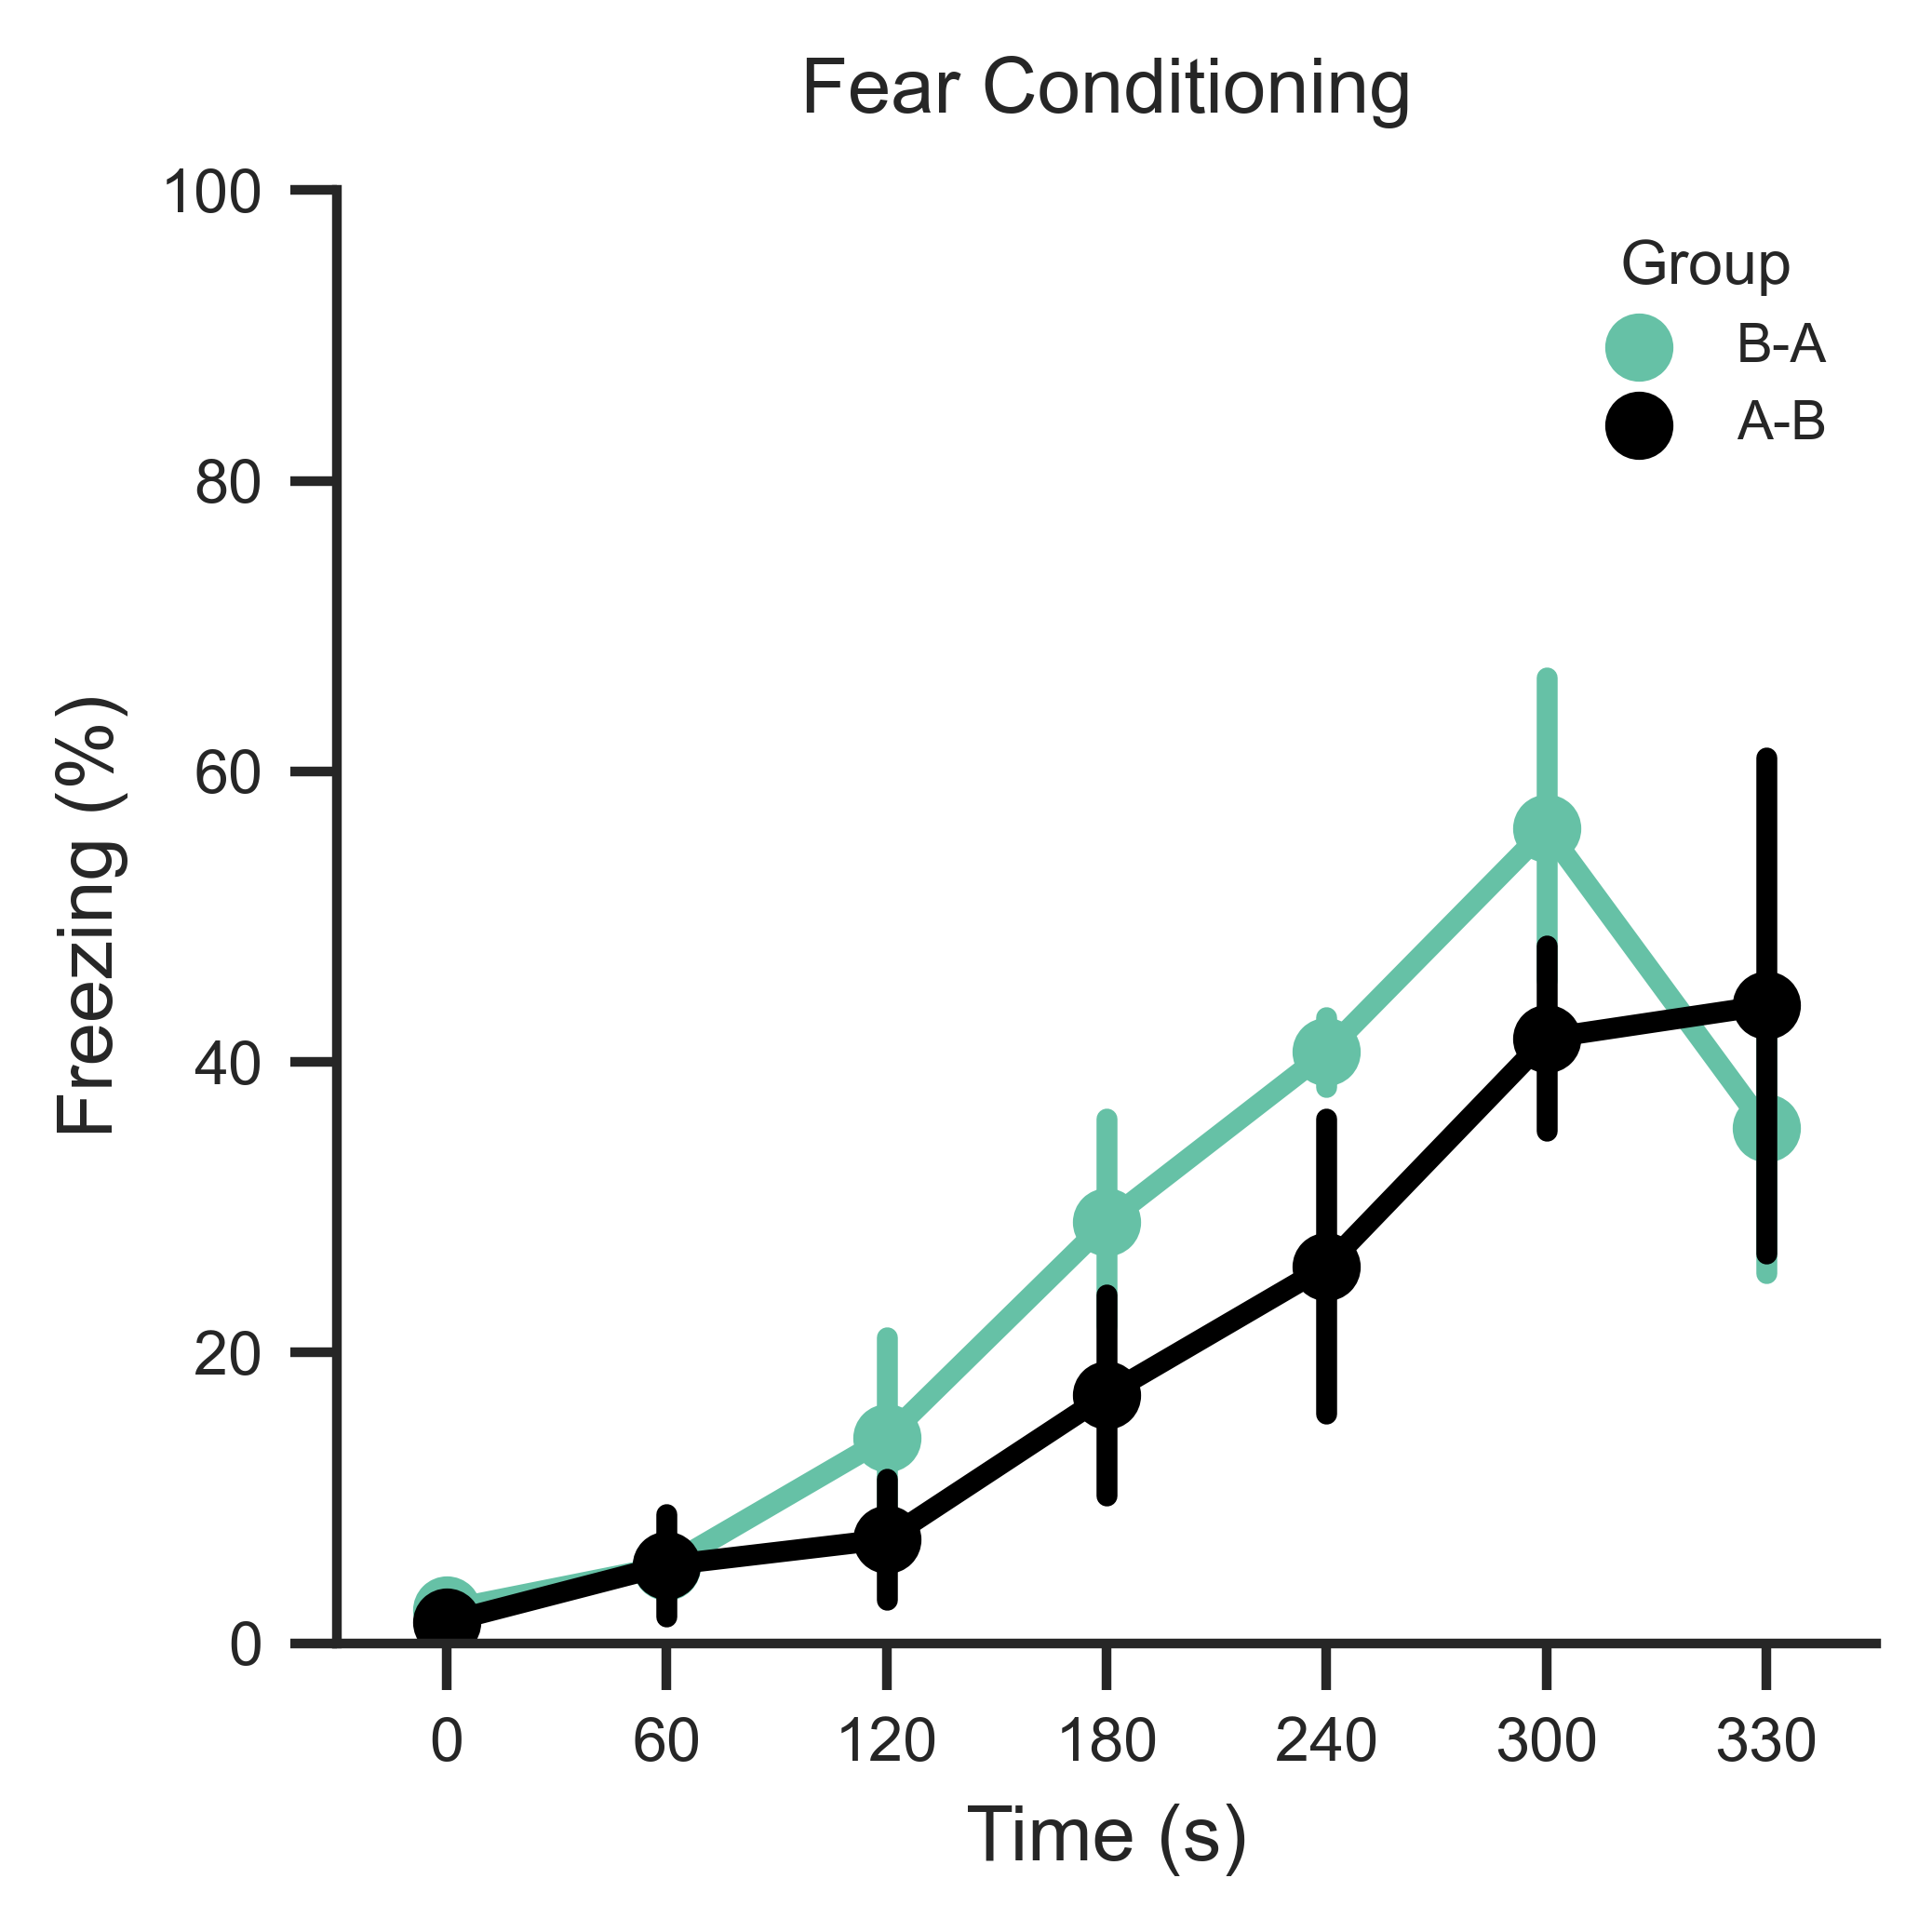

(<Figure size 2100x2100 with 1 Axes>,
 <Axes: title={'center': 'Fear Conditioning'}, xlabel='Time (s)', ylabel='Freezing (%)'>)

In [21]:
plot_freezing_across_time(df_fc, title='Fear Conditioning', save_path=r'/Users/suthardr/Desktop/fc_freezing_time_bygroup_clean.svg')

/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_85481/3312853139.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(


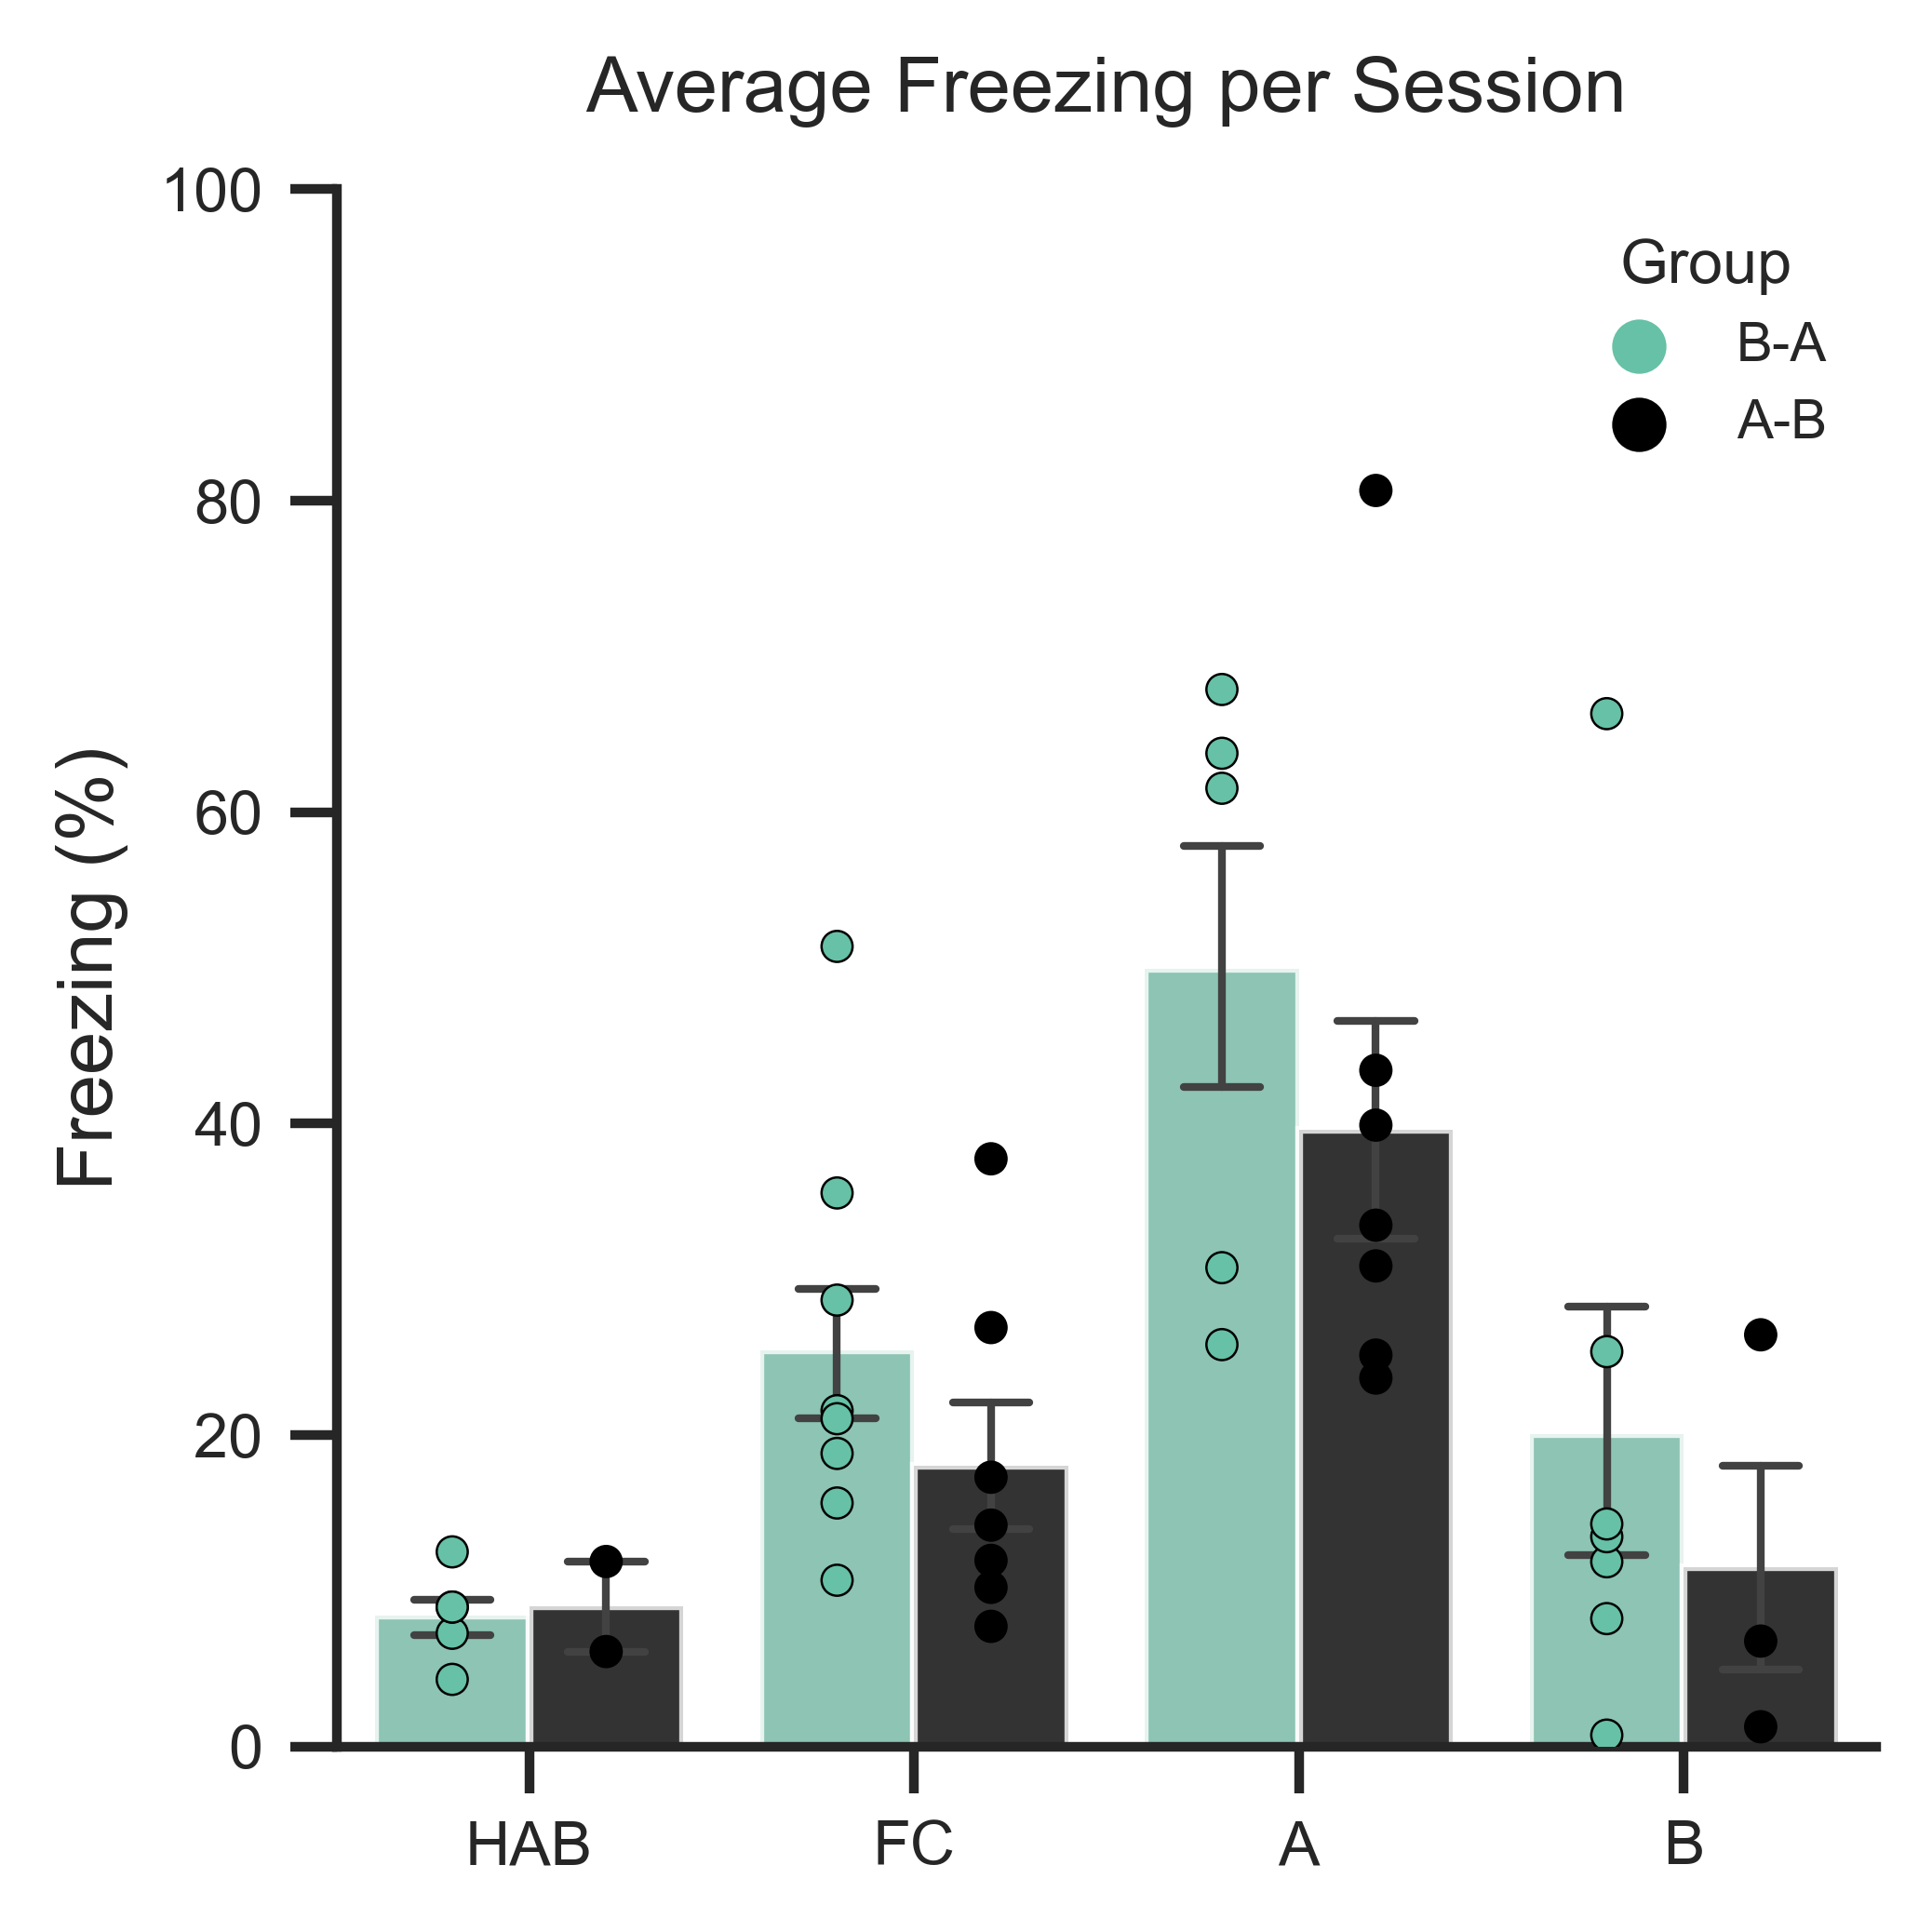

(<Figure size 2100x2100 with 1 Axes>,
 <Axes: title={'center': 'Average Freezing per Session'}, ylabel='Freezing (%)'>)

In [22]:
plot_avg_freezing(df_avg_all, title="Average Freezing per Session", save_path=r'/Users/suthardr/Desktop/allsessions_freezing_bygroup.svg')

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Custom pastel color palette (4 colors)
session_colors = {
    'HAB': '#FC9D9A',     # Soft Coral
    'FC': '#B39BC8',      # Dusty Lavender
    'A':   '#8CCFD0',     # Cool Sky Blue
    'B':   '#A8D5BA'      # Warm Taupe
}

order = ['HAB', 'FC', "A", "B"]

def plot_avg_freezing_all(df, title="", save_path=None):
    sns.set(style="ticks", font="Arial")
    plt.rcParams.update({'font.size': 8})

    fig, ax = plt.subplots(figsize=(2.5, 3.5), dpi=600)

    # Create a list of bar colors in the desired session order
    bar_colors = [session_colors[session] for session in order]

    # Barplot — assign color list manually using palette override
    sns.barplot(
        x='Session', y='freezing_percentage', data=df,
        order=order, ci=68, capsize=.2, errwidth=1,
        alpha=0.8, ax=ax, palette=bar_colors
    )

    # Stripplot — black dots on top of each bar
    sns.stripplot(
        x='Session', y='freezing_percentage', data=df,
        jitter=True, linewidth=0.3, edgecolor='black',
        size=3, order=order, ax=ax, color='black'
    )

    ax.legend_.remove() if ax.legend_ else None
    ax.set_ylabel('Freezing (%)', fontsize=10)
    ax.set_xlabel('', fontsize=10)
    ax.tick_params(labelsize=8)
    ax.set_ylim(0, 100)
    ax.set_title(title, fontsize=10, pad=10)
    sns.despine()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight', format='svg')
    plt.show()
    return fig, ax



def plot_freezing_across_time_all(df, title="", save_path=None):
    sns.set(style="ticks", font="Arial")
    plt.rcParams.update({'font.size': 8})

    fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)
    sns.set_palette(sns.color_palette(colors))

    # Pointplot without hue
    sns.pointplot(x='bin', y='freezing_percentage', data=df,
                  errorbar='se', ax=ax, color=colors[0])

    # Optional: stripplot without hue
    sns.stripplot(x='bin', y='freezing_percentage', data=df,
                  jitter=False, size=4, linewidth=0.3, edgecolor='black',
                  ax=ax, color='#66C1A6')

    ax.set_ylabel("Freezing (%)", fontsize=10)
    ax.set_xlabel("Time (s)", fontsize=10)
    ax.tick_params(labelsize=8)
    ax.set_ylim(0, 100)
    ax.set_title(title, fontsize=10, pad=10)

    # Replace x labels with your desired time points
    custom_labels = [0, 60, 120, 180, 240, 300, 330]
    ax.set_xticks(range(len(custom_labels)))
    ax.set_xticklabels(custom_labels)

    # Remove legend (no Group)
    ax.legend_.remove() if ax.legend_ else None

    sns.despine()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight', format='svg')
    plt.show()
    return fig, ax


/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_85481/1967112402.py:24: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(


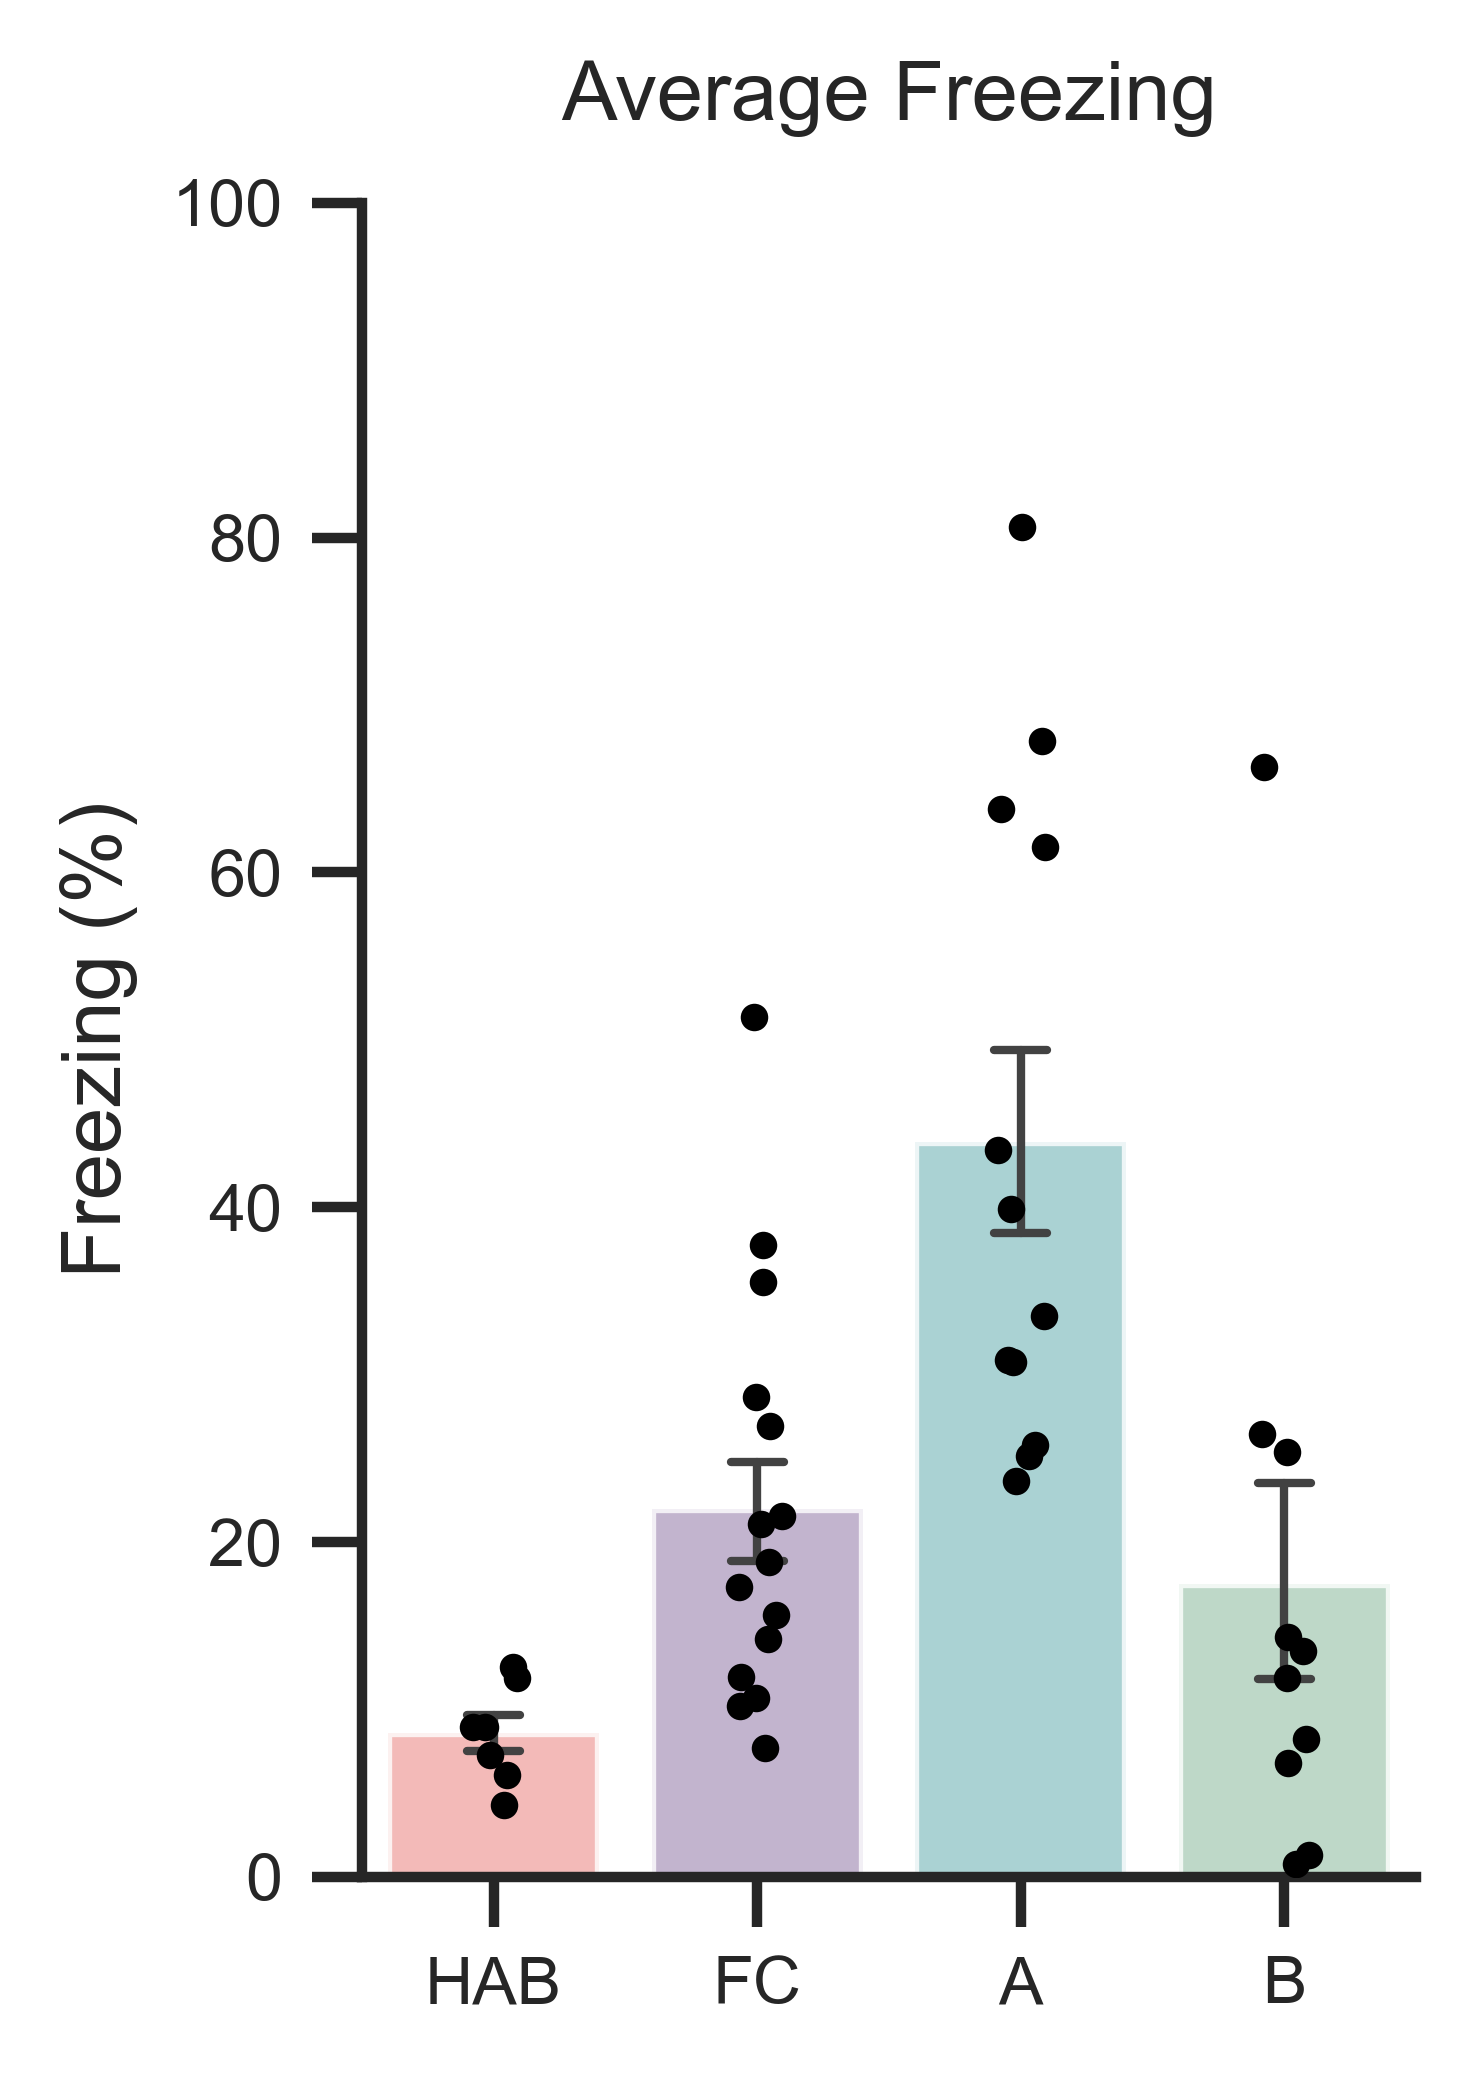

(<Figure size 1500x2100 with 1 Axes>,
 <Axes: title={'center': 'Average Freezing'}, ylabel='Freezing (%)'>)

In [24]:
plot_avg_freezing_all(df_avg_all, title="Average Freezing",
save_path=r'/Users/suthardr/Desktop/allsessions_freezing_concat_jitter.svg')

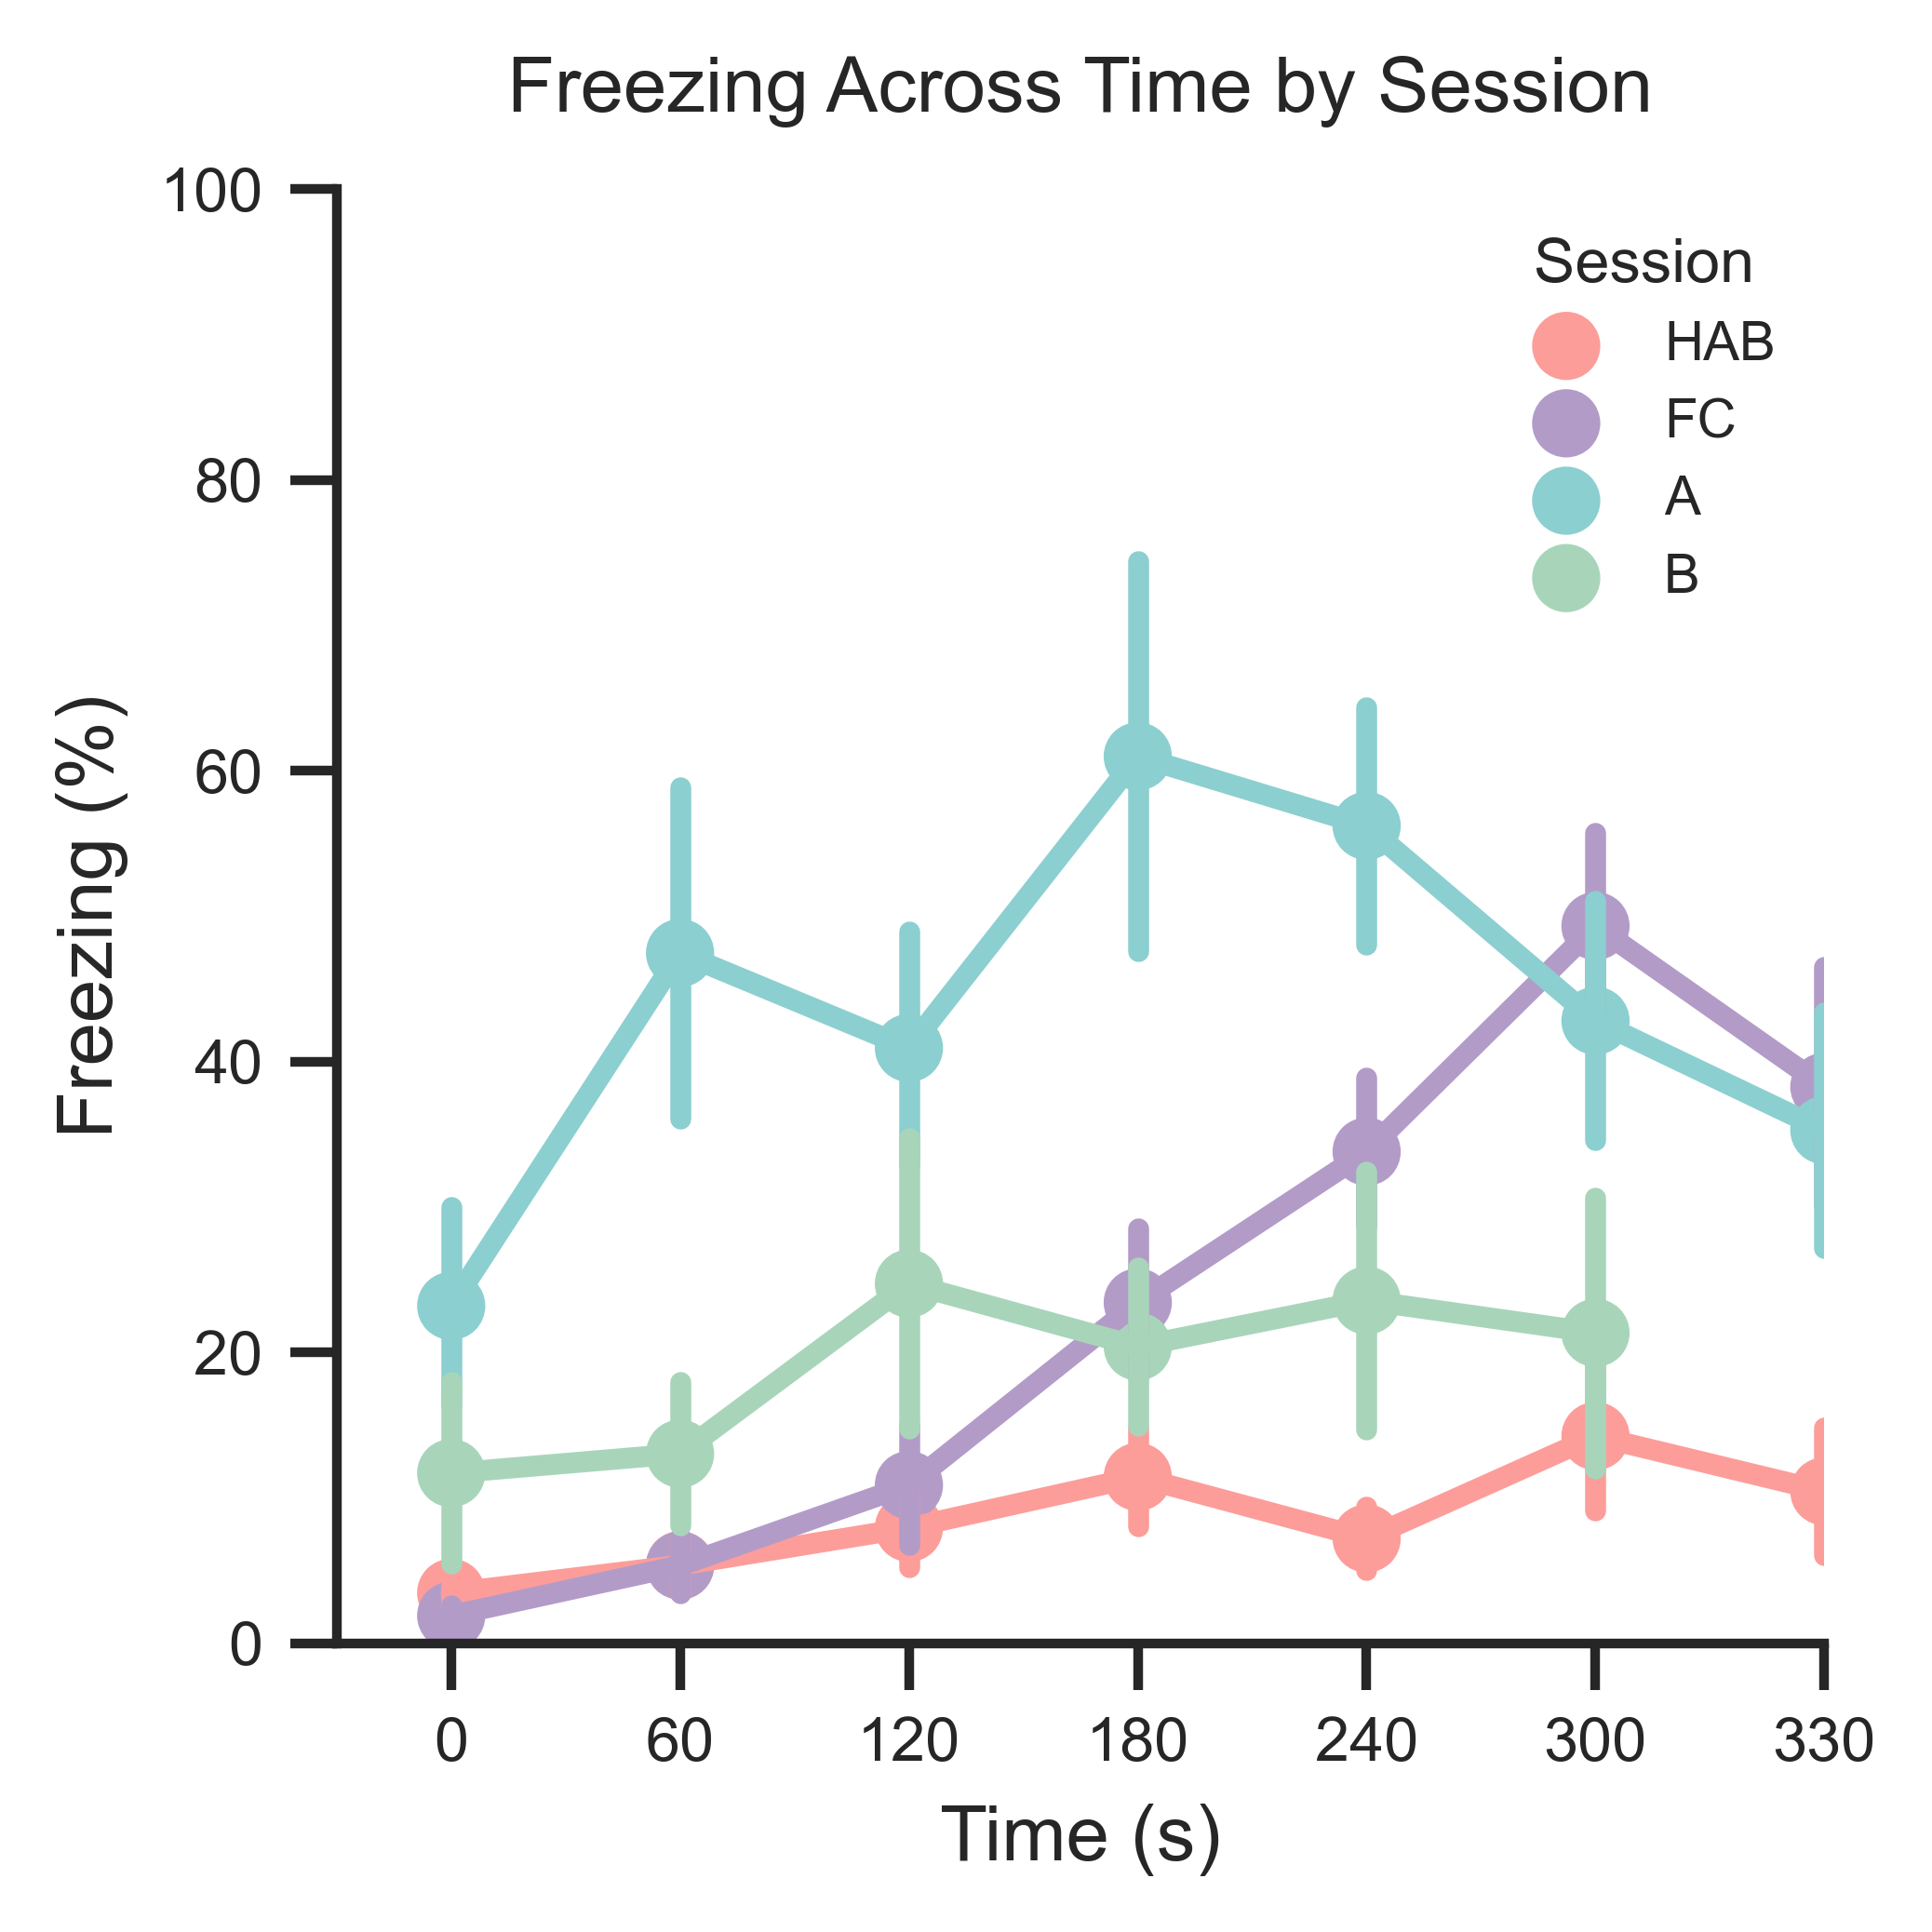

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Add a 'Session' column to each dataframe
df_hab['Session'] = 'HAB'
df_fc['Session'] = 'FC'
df_A['Session'] = 'A'
df_B['Session'] = 'B'

# Combine into one DataFrame
df_all_sessions = pd.concat([df_hab, df_fc, df_A, df_B], ignore_index=True)

# Custom hex colors per session (you can adjust as needed)
session_colors = {
    'HAB': '#FC9D9A',     # Soft Coral
    'FC': '#B39BC8',      # Dusty Lavender
    'A':   '#8CCFD0',     # Cool Sky Blue
    'B':   '#A8D5BA'
}

# Set aesthetics
sns.set(style="ticks", font="Arial")
plt.rcParams.update({'font.size': 8})

fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)

# Plot each session's data
for session in ['HAB', 'FC', 'A', 'B']:
    session_df = df_all_sessions[df_all_sessions['Session'] == session]
    sns.pointplot(
        x='bin', y='freezing_percentage', data=session_df,
        errorbar='se', label=session, ax=ax, color=session_colors[session]
    )

# Customize plot
ax.set_ylabel("Freezing (%)", fontsize=10)
ax.set_xlabel("Time (s)", fontsize=10)
ax.tick_params(labelsize=8)
ax.set_ylim(0, 100)
ax.set_title("Freezing Across Time by Session", fontsize=10, pad=10)

# Replace bin labels with time (adjust if needed)
custom_labels = [0, 60, 120, 180, 240, 300, 330]
ax.set_xticks(range(len(custom_labels)))
ax.set_xticklabels(custom_labels)

# Legend
ax.legend(title="Session", fontsize=7, title_fontsize=8, frameon=False, loc='upper right')

sns.despine()
plt.tight_layout()

# Optional: save
plt.savefig(r'/Users/suthardr/Desktop/allsessions_freezing_concat_acrosstime.svg', format='svg', bbox_inches='tight')

plt.show()

In [41]:
df_avg_all = df_avg_all.reset_index(drop=True)


In [50]:
df_avg_all

,Mouse,Session,Group,Sex,freezing_percentage
0,astroF10,FC,B-A,Female,51.382857
1,astroF3,FC,B-A,Female,18.827143
2,astroF5,FC,B-A,Female,21.570238
3,astroF6,FC,A-B,Female,17.299048
4,astroF7,FC,A-B,Female,10.227381
5,astroF8,FC,B-A,Female,28.673333
6,astroF9,FC,B-A,Female,35.551905
7,astroM10,FC,A-B,Male,37.745238
8,astroM3,FC,A-B,Male,26.909167
9,astroM4,FC,A-B,Male,7.724722


In [60]:
import statsmodels.formula.api as smf

# Your dataframe: df with columns 'freezing_percentage', 'Group', 'Session', 'Mouse'
df = df_avg_all
# Convert categorical variables to categorical dtype (if not already)
df['Group'] = df['Group'].astype('category')
df['Session'] = df['Session'].astype('category')
df['Mouse'] = df['Mouse'].astype('category')
df['Sex'] = df['Sex'].astype('category')

df['Session'] = pd.Categorical(df['Session'], categories=['HAB', 'A', 'B', 'FC'], ordered=False)

# Fit a mixed-effects model with random intercepts for Mouse
model = smf.mixedlm("freezing_percentage ~ Group * Session", data=df, groups=df["Mouse"])

result = model.fit()
print(result.summary())


                Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  freezing_percentage
No. Observations:   44       Method:              REML               
No. Groups:         15       Scale:               223.3289           
Min. group size:    1        Log-Likelihood:      -156.6673          
Max. group size:    4        Converged:           Yes                
Mean group size:    2.9                                              
---------------------------------------------------------------------
                           Coef.  Std.Err.   z   P>|z|  [0.025 0.975]
---------------------------------------------------------------------
Intercept                   6.536   11.641 0.561 0.574 -16.279 29.351
Group[T.B-A]                0.850   13.265 0.064 0.949 -25.149 26.849
Session[T.A]               33.057   12.796 2.583 0.010   7.977 58.137
Session[T.B]                4.058   13.934 0.291 0.771 -23.251 31.368
Session[T.FC]              11.477   

In [ ]:
#freezing_percentage ~ Sex + Session
#males freeze ~7% less than females on average across sessons; not significant
#increase in freezing A vs HAB significant (39%)
#increase in freezing B vs HAB but not significant (11%)
#increase in freezing FC vs HAB significant (18%)

#freezing_percentage ~ Group + Session *same Session results as above
#group B-A freezes 1% more than A-B across sessions but not significant
#increase in freezing A vs HAB significant (38-39%)
#increase in freezing B vs HAB but not significant (10-11%)
#increase in freezing FC vs HAB significant (16-17%)